# A-D Wandler

In [177]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt

font = {'family' : 'serif',
        'weight' : 'normal',
        'size'   : 11}

matplotlib.rc('font', **font)

## Berechnung der Umsetzerkennlinien

ADC Parameter

In [178]:
u_fsr = 5
n_bits = 4
n_levels = 2 ** n_bits
codes = np.arange(-n_levels/2, n_levels/2)

### Ideale AD Umsetzerkennlinie

In [179]:
# Stufenmittelpunkte
u_mid = np.arange(-u_fsr/2, +u_fsr/2, u_fsr / n_levels)
# Stufenbreite
u_width = np.ones(n_levels) * u_fsr / n_levels
# Umschaltspunkte
u_edge = u_mid + u_width / 2

Ausgabe der Idealen Kennlinie

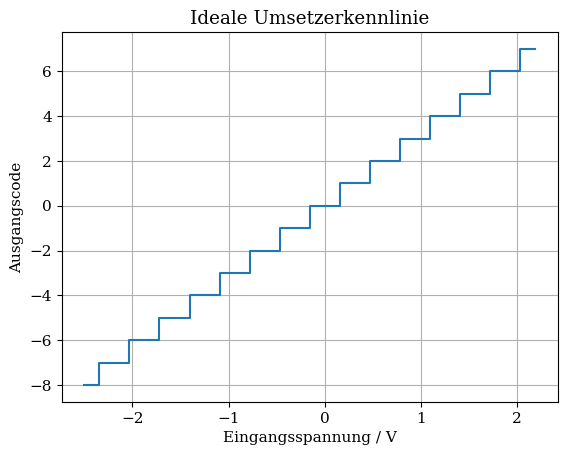

In [180]:
plt.step(u_mid, codes, where='mid')
plt.title('Ideale Umsetzerkennlinie')
plt.xlabel('Eingangsspannung / V')
plt.ylabel('Ausgangscode')
plt.grid(True)
plt.show()

### Reale Messwerte

Schwellen des realen AD Umsetzers messen

In [181]:
# starte bei code -8
u_edge_flash = np.array([
    -2.233,
    -2.085,
    -1.748,
    -1.452,
    -1.102,
    -0.895,
    -0.541,
    -0.404,
    -0.039,
    0.045,
    0.787,
    1.118,
    1.428,
    1.612,
    1.939
])

In [182]:
u_edge_real = np.array([
    -2.578, # -8 -> -7
    -2.179, # -7 -> -6
    -1.78,  # -6 -> -5
    -1.61,  # -5 -> -4
    -1.234, # -4 -> -3
    -0.913, # -3 -> -2
    -0.487, # -2 -> -1
    -0.135, # -1 -> 0
    0.498, # 0 -> 1
    0.876, # 1 -> 2
    1.217, # 2 -> 3
    1.339, # 3 -> 4
    1.785, # 4 -> 5
    2.113, # 5 -> 6
    2.533 # 6 -> 7
])

In [183]:
u_dac = np.array([
    0.204, # -8
    0.250, # -7
    0.52, # -6
    0.73, # -5
    0.987, # -4
    1.192, # -3
    1.46, # -2
    1.67, # -1
    2.500, # 0
    2.71, # 1
    2.98, # 2
    3.19, # 3
    3.45, # 4
    3.65, # 5
    3.92, # 6
    4.14, # 7
])

In [184]:
u_edge_real = np.array([
    -2.206, # -8 -> -7
    -1.922, # -7 -> -6
    -1.626, # -6 -> -5
    -1.265, # -5 -> -4
    -0.951, # -4 -> -3
    -0.609, # -3 -> -2
    -0.353, # -2 -> -1
    -0.011, # -1 -> 0
    0.293, # 0 -> 1
    0.540, # 1 -> 2
    0.873, # 2 -> 3
    1.281, # 3 -> 4
    1.566, # 4 -> 5
    1.879, # 5 -> 6
    2.155 # 6 -> 7
])

### Auswertung

Korrektur der Werte

In [185]:
u_edge_diff = abs(u_edge_real - u_edge[:-1])

pos_end = u_edge_diff[-2]
neg_end = u_edge_diff[0]
null_pt = u_edge_diff[int(n_levels/2)]

n_vals = n_levels-2
u_edge_korr = np.array([
	u_edge_real[i] - (neg_end*i + pos_end*(n_vals-i))/n_vals
	for i in range(n_vals+1)
])

In [186]:
u_width_real = np.array([
	u_edge_korr[i+1] - u_edge_korr[i]
	for i in range(n_levels-2)
])
u_mid_real = u_edge_korr[:-1] + u_width_real / 2

u_width_diff = np.abs(u_width_real - u_width[1:-1])
u_mid_diff = np.abs(u_mid_real - u_mid[1:-1])

dnl = np.max(np.abs(u_width_diff))
inl = np.max(np.abs(u_mid_diff))

In [187]:
errors = {
    'pos_end': pos_end,
    'neg_end': neg_end,
    'null_pt': null_pt,
    'dnl': dnl,
    'inl': inl
}
pd.DataFrame(data=errors, index=[''])

,pos_end,neg_end,null_pt,dnl,inl
,0.16025,0.13775,0.13675,0.097107,0.063482


In [188]:
df_codes = pd.DataFrame({ 'Code': codes })
df = pd.merge(pd.DataFrame({
	'Code': codes[:-1],
	'U_edge_real': u_edge_real,
	'U_edge_ideal': u_edge[:-1],
	'U_edge_diff': u_edge_diff
}), pd.DataFrame({
	'Code': codes[1:-1],
	'U_width_real': u_width_real,
	'U_width_ideal': u_width[1:-1],
	'U_width_diff': u_width_diff,
	'U_mittel_real': u_mid_real,
	'U_mittel_ideal': u_mid[1:-1],
	'U_mittel_diff': u_mid_diff
}), how='left', on='Code')

# merge dataframes on code
pd.merge(df_codes, df, how='left', on='Code')

,Code,U_edge_real,U_edge_ideal,U_edge_diff,U_width_real,U_width_ideal,U_width_diff,U_mittel_real,U_mittel_ideal,U_mittel_diff
0,-8.0,-2.206,-2.34375,0.13775,NaN,NaN,NaN,NaN,NaN,NaN
1,-7.0,-1.922,-2.03125,0.10925,0.285607,0.3125,0.026893,-2.223446,-2.1875,0.035946
2,-6.0,-1.626,-1.71875,0.09275,0.297607,0.3125,0.014893,-1.931839,-1.8750,0.056839
3,-5.0,-1.265,-1.40625,0.14125,0.362607,0.3125,0.050107,-1.601732,-1.5625,0.039232
4,-4.0,-0.951,-1.09375,0.14275,0.315607,0.3125,0.003107,-1.262625,-1.2500,0.012625
5,-3.0,-0.609,-0.78125,0.17225,0.343607,0.3125,0.031107,-0.933018,-0.9375,0.004482
6,-2.0,-0.353,-0.46875,0.11575,0.257607,0.3125,0.054893,-0.632411,-0.6250,0.007411
7,-1.0,-0.011,-0.15625,0.14525,0.343607,0.3125,0.031107,-0.331804,-0.3125,0.019304
8,0.0,0.293,0.15625,0.13675,0.305607,0.3125,0.006893,-0.007196,0.0000,0.007196
9,1.0,0.540,0.46875,0.07125,0.248607,0.3125,0.063893,0.269911,0.3125,0.042589


Ausgabe der Realen Kennlinie über der Idealen

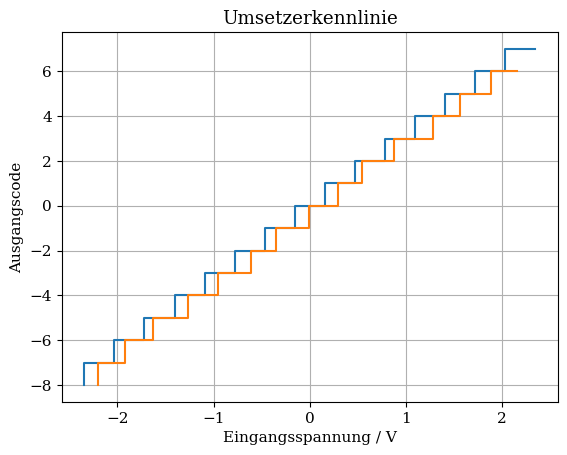

In [189]:
plt.step(u_edge, codes, where='pre')
plt.step(u_edge_real, codes[:-1], where='pre')
plt.title('Umsetzerkennlinie')
plt.xlabel('Eingangsspannung / V')
plt.ylabel('Ausgangscode')
plt.grid(True)
plt.show()